In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.nn import functional as F

import tiktoken

# Layer Normalization

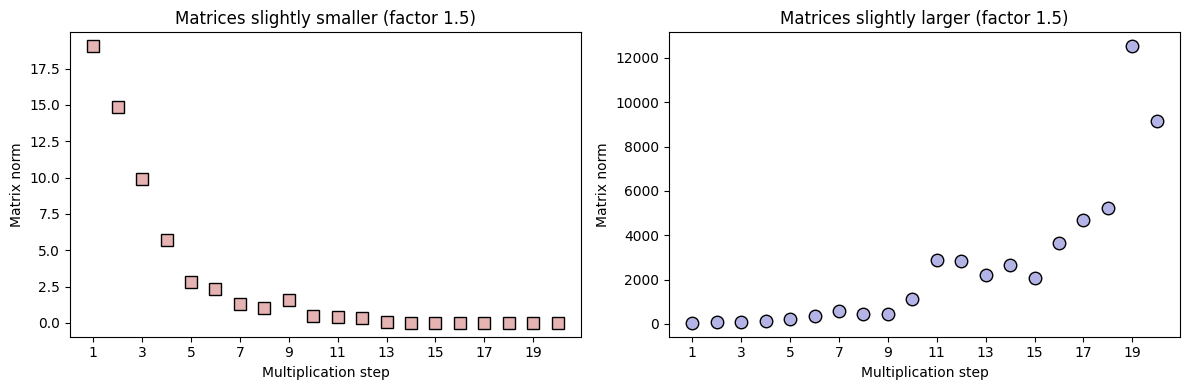

In [ ]:
scale_factor = 1.5
num_multiplications = 20

random_small = torch.randn(30, 30)
random_big = torch.randn(30, 30)

# initialize the results
norms = torch.zeros(num_multiplications, 2)

# loop over the number of multiplications
for i in range(num_multiplications):
    random_small *= torch.randn(30, 30) * (1/scale_factor)
    norms[i, 0] = torch.norm(random_small)

    random_big *= torch.randn(30, 30) * scale_factor
    norms[i, 1] = torch.norm(random_big)


# draw the plots
_,axs = plt.subplots(1,2,figsize=(12,4))
axs[0].plot(range(1,num_multiplications+1),norms[:,0],'ks',markersize=9,markerfacecolor=[.9,.7,.7])
axs[1].plot(range(1,num_multiplications+1),norms[:,1],'ko',markersize=9,markerfacecolor=[.7,.7,.9])

for a,t in zip(axs,['smaller','larger']):
  a.set(xticks=range(1,num_multiplications+1,2),
        xlabel='Multiplication step',
        ylabel='Matrix norm',
        title=f'Matrices slightly {t} (factor {scale_factor})')

plt.tight_layout()
plt.show()

# we observe that one risk of matrix multiplication, is that they could vanish or exploding

In [6]:
n_in = 3
n_out = 10

A = torch.randn(n_in, n_out) * 2 + 3
torch.round(A)

tensor([[ 3., -1.,  4.,  3.,  7., -0.,  1.,  3.,  5.,  4.],
        [ 5.,  1.,  4.,  8.,  5.,  4.,  3.,  2.,  6.,  5.],
        [ 5.,  6.,  3.,  4.,  2.,  1.,  1.,  1.,  1.,  3.]])

In [15]:
# create a LayorNorm object instance
layer_norm = nn.LayerNorm(n_out) # repeat with (n_in, n_out)
layer_norm # eps goes into the denominator when normalizing to avoid inestability

LayerNorm((10,), eps=1e-05, elementwise_affine=True)

In [16]:
normA = layer_norm(A)
print(A.shape, normA.shape)

print('Original matrix:\n',torch.round(A))
print('\nLayer-normed matrix:\n',torch.round(normA))

torch.Size([3, 10]) torch.Size([3, 10])
Original matrix:
 tensor([[ 3., -1.,  4.,  3.,  7., -0.,  1.,  3.,  5.,  4.],
        [ 5.,  1.,  4.,  8.,  5.,  4.,  3.,  2.,  6.,  5.],
        [ 5.,  6.,  3.,  4.,  2.,  1.,  1.,  1.,  1.,  3.]])

Layer-normed matrix:
 tensor([[-0., -2.,  0.,  0.,  2., -1., -1.,  0.,  1.,  1.],
        [ 0., -2., -0.,  2.,  0., -0., -1., -1.,  1.,  0.],
        [ 1.,  2.,  0.,  1., -0., -1., -1., -1., -1.,  0.]],
       grad_fn=<RoundBackward0>)


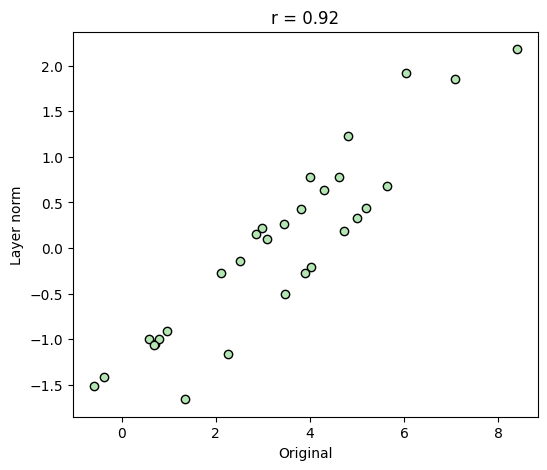

In [17]:
# how does layernorm change the matrix?

# convenience variables
a1 = A.detach().flatten()
a2 = normA.detach().flatten()

# correlation between them
r = torch.sum( (a1-a1.mean()) * (a2-a2.mean()) )
r /= torch.sqrt( torch.sum((a1-a1.mean())**2) * torch.sum((a2-a2.mean())**2) )

# scatter plot!
plt.figure(figsize=(6,5))
plt.plot(a1,a2,'ko',markerfacecolor=[.7,.9,.7])

# labels etc
plt.gca().set(xlabel='Original',ylabel='Layer norm',
              title=f'r = {r:.2f}')
plt.show()

# we can see that now the mean has shifted from ~4 to 0, and the values have been shrink from [0, 8] to [-2, 2] aprox.


In [ ]:
print('ORIGINAL: mean across columns for each row:')
print(f'  {torch.mean(A,axis=1)}\n')
print('LAYERNORM: mean across columns for each row:')
print(f'  {torch.mean(normA,axis=1).detach()}\n')

print('ORIGINAL: std across columns for each row:')
print(f'  {torch.std(A,axis=1)}\n')
print('LAYERNORM: std across columns for each row:')
print(f'  {torch.std(normA,axis=1).detach()}\n')

# it has been applied to the rows and not to the rows,
# in fact if we visualize the norm across the columns:
print('\n\nLAYERNORM: mean across rows for each column:')
print(f'  {torch.mean(normA,axis=0).detach()}\n')
print('LAYERNORM: std across rows for each column:')
print(f'  {torch.std(normA,axis=0).detach()}\n')

ORIGINAL: mean across columns for each row:
  tensor([2.8527, 4.3951, 2.5969])

LAYERNORM: mean across columns for each row:
  tensor([-7.7486e-08,  1.1921e-07, -5.9605e-08])

ORIGINAL: std across columns for each row:
  tensor([2.4041, 1.9358, 1.8932])

LAYERNORM: std across columns for each row:
  tensor([1.0541, 1.0541, 1.0541])



LAYERNORM: mean across rows for each column:
  tensor([ 0.4229, -0.4161,  0.1229,  1.0208,  0.6718, -0.9119, -0.8307, -0.6034,
         0.1315,  0.3921])

LAYERNORM: std across rows for each column:
  tensor([0.7191, 2.0223, 0.3143, 1.0587, 1.0863, 0.5860, 0.2859, 0.7622, 1.0317,
        0.2172])



In [23]:
print(f"Value of 'gamma' (stretch/scale param): {layer_norm.weight}\n")
print(f"Value of 'beta': (shift param): {layer_norm.bias}\n")

# we can see they have requires_grad, since these numbers in realy are learnable, they can be learnt
layer_norm.weight = torch.nn.Parameter(torch.ones(n_out)*3)
layer_norm.bias = torch.nn.Parameter(torch.ones(n_out)*5)

layer_norm.weight, layer_norm.bias

Value of 'gamma' (stretch/scale param): Parameter containing:
tensor([3., 3., 3., 3., 3., 3., 3., 3., 3., 3.], requires_grad=True)

Value of 'beta': (shift param): Parameter containing:
tensor([5., 5., 5., 5., 5., 5., 5., 5., 5., 5.], requires_grad=True)



(Parameter containing:
 tensor([3., 3., 3., 3., 3., 3., 3., 3., 3., 3.], requires_grad=True),
 Parameter containing:
 tensor([5., 5., 5., 5., 5., 5., 5., 5., 5., 5.], requires_grad=True))

In [ ]:
normAnew = layer_norm(A)

print('NEW LAYERNORM: mean across columns for each row:')
print(f'  {torch.mean(normAnew,axis=1).detach()}\n')
print('NEW LAYERNORM: std across columns for each row:')
print(f'  {torch.std(normAnew,axis=1).detach()}\n')
# we can see how now the new mean and std have change, since we have modified LayerNorm.

ORIGINAL: mean across columns for each row:
  tensor([2.8527, 4.3951, 2.5969])

ORIGINAL: std across columns for each row:
  tensor([2.4041, 1.9358, 1.8932])

NEW LAYERNORM: mean across columns for each row:
  tensor([5.0000, 5.0000, 5.0000])

NEW LAYERNORM: std across columns for each row:
  tensor([3.1623, 3.1623, 3.1623])



# What if we now we do the norm col and row wise

In [25]:
layer_norm = nn.LayerNorm((n_in, n_out))
normA = layer_norm(A)

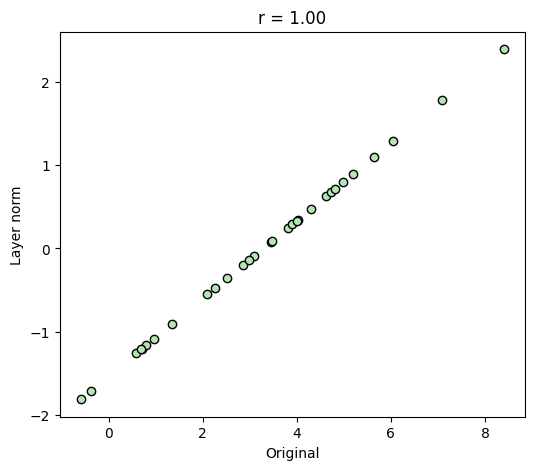

In [26]:
# convenience variables
a1 = A.detach().flatten()
a2 = normA.detach().flatten()

# correlation between them
r = torch.sum( (a1-a1.mean()) * (a2-a2.mean()) )
r /= torch.sqrt( torch.sum((a1-a1.mean())**2) * torch.sum((a2-a2.mean())**2) )

# scatter plot!
plt.figure(figsize=(6,5))
plt.plot(a1,a2,'ko',markerfacecolor=[.7,.9,.7])

# labels etc
plt.gca().set(xlabel='Original',ylabel='Layer norm',
              title=f'r = {r:.2f}')
plt.show()

In [ ]:
print('LAYERNORM: mean across columns for each row:')
print(f'  {torch.mean(normA,axis=1).detach()}\n')
print('LAYERNORM: std across columns for each row:')
print(f'  {torch.std(normA,axis=1).detach()}\n')

print('LAYERNORM: mean across rows for each column:')
print(f'  {torch.mean(normA,axis=0).detach()}\n')
print('LAYERNORM: std across rows for each column:')
print(f'  {torch.std(normA,axis=0).detach()}\n')

# now neither the cols or the rows have a pure N(0, 1) distribution, since it is not row-wise or col-wise, 
# but a combination of both

LAYERNORM: mean across columns for each row:
  tensor([-0.2007,  0.5212, -0.3205])

LAYERNORM: std across columns for each row:
  tensor([1.1253, 0.9061, 0.8862])

LAYERNORM: mean across rows for each column:
  tensor([ 0.3458, -0.4743,  0.1340,  0.8797,  0.7080, -0.8753, -0.7765, -0.4946,
         0.1737,  0.3796])

LAYERNORM: std across rows for each column:
  tensor([0.6075, 1.5952, 0.2888, 1.3289, 1.1784, 1.0408, 0.7530, 0.5830, 1.2214,
        0.4773])



# Batch Norm vs Layer Norm

In [ ]:
x = torch.randn(8, 64, 32, 32)   # (N=8, C=64, H=32, W=32)

# nn.BatchNorm2d strictly expects a 4D tensor of shape (N, C, H, W) 
# and always normalizes along the channel dimension (dim=1, the second one)


bn = nn.BatchNorm2d(64)           # 1 mean/var per channel (64 stats)
ln = nn.LayerNorm([64, 32, 32])   # 1 mean/var per sample (8 stats)

y_bn = bn(x)   # stats across N, H, W for each C
y_ln = ln(x)   # stats across C, H, W for each N

y_bn.shape, y_ln.shape

(torch.Size([8, 64, 32, 32]), torch.Size([8, 64, 32, 32]))